## Step 0 - import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1 — load and audit

In [2]:
df_raw = pd.read_csv("Data_MLB_2025.csv")
print(df_raw.shape)

(14096, 95)


In [3]:
df_raw.dtypes

game_year               int64
game_date                 str
player_name               str
pitcher                 int64
batter                  int64
                       ...   
spin_axis             float64
delta_home_win_exp    float64
delta_run_exp         float64
bat_speed             float64
swing_length          float64
Length: 95, dtype: object

In [4]:
df_raw.duplicated().sum()

0

In [5]:
df_raw.head()

,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,2025,2025-09-30,"Ashcraft, Graham",668933,605141,0,0,8,Bot,73,...,10,10,5,Standard,Standard,42.0,0.0,0.041,NaN,NaN
1,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,0,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,-0.050,NaN,NaN
2,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,1,8,Bot,73,...,10,10,5,Standard,Standard,23.0,0.0,-0.061,65.0,6.0
3,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,39.0,0.0,0.000,53.1,7.2
4,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,0.043,NaN,NaN


In [6]:
df_raw.describe()

,game_year,pitcher,batter,balls,strikes,inning,at_bat_number,pitch_number,release_speed,release_pos_x,...,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
count,14096.0,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,...,14096.000000,14096.00000,14096.000000,14096.000000,14096.000000,14089.000000,14096.000000,14096.000000,6704.000000,6704.000000
mean,2025.0,654432.648127,646575.503689,0.872375,0.916359,5.273624,40.607406,2.925227,90.682740,-0.796971,...,2.110031,1.94431,2.223184,2.057463,2.110031,176.305203,0.000167,-0.002535,69.569391,7.244824
std,0.0,60782.502545,49297.380592,0.968588,0.829502,3.027925,25.720786,1.741043,6.008374,1.893833,...,2.523059,2.20987,2.625899,2.334641,2.523059,74.953615,0.027601,0.222230,9.545128,1.054472
min,2025.0,453286.000000,457759.000000,0.000000,0.000000,1.000000,1.000000,1.000000,69.200000,-4.330000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,-0.509000,-0.530000,2.000000,0.500000
25%,2025.0,608718.000000,608701.000000,0.000000,0.000000,3.000000,20.000000,1.000000,86.200000,-2.160000,...,0.000000,0.00000,0.000000,0.000000,0.000000,132.000000,0.000000,-0.063000,67.100000,6.600000
50%,2025.0,666200.000000,664023.000000,1.000000,1.000000,5.000000,39.000000,3.000000,91.600000,-1.600000,...,1.000000,1.00000,1.000000,1.000000,1.000000,201.000000,0.000000,-0.039000,71.200000,7.300000
75%,2025.0,682120.000000,676391.000000,1.000000,2.000000,7.000000,59.000000,4.000000,95.700000,1.040000,...,3.000000,3.00000,3.000000,3.000000,3.000000,222.000000,0.000000,0.039000,74.600000,8.000000
max,2025.0,813349.000000,807799.000000,3.000000,2.000000,18.000000,153.000000,13.000000,104.500000,4.100000,...,13.000000,13.00000,13.000000,13.000000,13.000000,360.000000,0.412000,2.696000,87.600000,10.400000


## Step 2 — filter to blue jays pitching

In [7]:
# game_type == 'R' filter skipped — dataset is postseason only ('P')
df_raw["game_type"].unique()

<StringArray>
['F', 'D', 'L', 'W']
Length: 4, dtype: str

In [8]:
tor_games = df_raw[(df_raw["home_team"] == "TOR") | (df_raw["away_team"] == "TOR")]

df = tor_games[
    ((tor_games["home_team"] == "TOR") & (tor_games["inning_topbot"] == "Top"))
    | ((tor_games["away_team"] == "TOR") & (tor_games["inning_topbot"] == "Bot"))
].copy().reset_index(drop=True)

print(f"Rows: {len(df):,}\nPitchers: {df['pitcher'].nunique()}\nGames: {df['game_pk'].nunique()}")

Rows: 2,788
Pitchers: 15
Games: 18


## Step 3 — drop depriciated and empty columns

In [9]:
fully_empty = df.columns[df.isnull().all()].tolist()
duplicate_cols = [c for c in df.columns if c.endswith(".1") or c.endswith(".2")]
print(duplicate_cols)

df = df.drop(columns=fully_empty + duplicate_cols)
print(f"Dropped {len(fully_empty + duplicate_cols)} columns\nRemaining: {df.shape[1]}")

['fielder_2.1', 'fielder_2.2']
Dropped 10 columns
Remaining: 85


## Step 4 — missing values

In [10]:
missing = df.isna().sum()
missing[missing != 0].sort_values(ascending=False)

on_3b                              2599
launch_speed_angle                 2340
estimated_ba_using_speedangle      2340
bb_type                            2337
hc_x                               2337
hc_y                               2337
on_2b                              2315
hit_location                       2188
estimated_woba_using_speedangle    2092
woba_denom                         2090
events                             2087
iso_value                          2087
babip_value                        2087
woba_value                         2087
launch_angle                       1952
launch_speed                       1952
hit_distance_sc                    1952
on_1b                              1903
bat_speed                          1516
swing_length                       1516
dtype: int64

In [11]:
df[["on_1b", "on_2b", "on_3b"]] = df[["on_1b", "on_2b", "on_3b"]].fillna(0)

In [12]:
core_cols = ["release_speed", "release_spin_rate", "plate_x", "plate_z", "effective_speed"]
before = len(df)
df = df.dropna(subset=core_cols)
print(f"Dropped {before - len(df)} rows with missing core mechanics")

Dropped 0 rows with missing core mechanics


## Step 5 — convert to date time object type

In [13]:
df["game_date"] = pd.to_datetime(df["game_date"], format="%Y-%m-%d")

## Step 6 — remove outliers (IQR per pitch type)

In [14]:
mechanics_cols = ["release_speed", "release_spin_rate", "effective_speed"]

if "release_extension" in df.columns:
    mechanics_cols.append("release_extension")

before = len(df)
keep = pd.Series(True, index=df.index)

for col in mechanics_cols:
    col_keep = pd.Series(True, index=df.index)

    for pitch in df["pitch_name"].dropna().unique():
        pitch_rows = df["pitch_name"] == pitch
        pitch_values = df.loc[pitch_rows, col]

        q1 = pitch_values.quantile(0.25)
        q3 = pitch_values.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        within_range = (df.loc[pitch_rows, col] >= lower) & (df.loc[pitch_rows, col] <= upper)
        col_keep.loc[pitch_rows] = within_range

    keep = keep & col_keep

df = df[keep].copy().reset_index(drop=True)

print(f'Outlieers dropped: {before - len(df)}')
df["pitch_name"].dropna().unique()

Outlieers dropped: 166


<StringArray>
['4-Seam Fastball',         'Sweeper',          'Slider',    'Split-Finger',
          'Sinker',   'Knuckle Curve',          'Cutter',        'Changeup',
       'Curveball']
Length: 9, dtype: str

## Step 7 — engineer shared features

In [15]:
df["cum_pitch_count"] = df.groupby(["game_pk", "pitcher"]).cumcount() + 1
df["game_phase"] = ""

df.loc[df["inning"] <= 3, "game_phase"] = "Early"
df.loc[(df["inning"] >= 4) & (df["inning"] <= 6), "game_phase"] = "Mid"
df.loc[df["inning"] >= 7, "game_phase"] = "Late"

df["score_diff"] = df["bat_score"] - df["fld_score"]

cols = ["cum_pitch_count", "game_phase", "score_diff"]
df[cols].describe()

,cum_pitch_count,score_diff
count,2622.000000,2622.000000
mean,26.181541,-1.199466
std,24.228103,3.261857
min,1.000000,-12.000000
25%,7.000000,-2.000000
50%,16.000000,0.000000
75%,43.000000,0.000000
max,104.000000,7.000000


## Step 8 — EDA visualisations

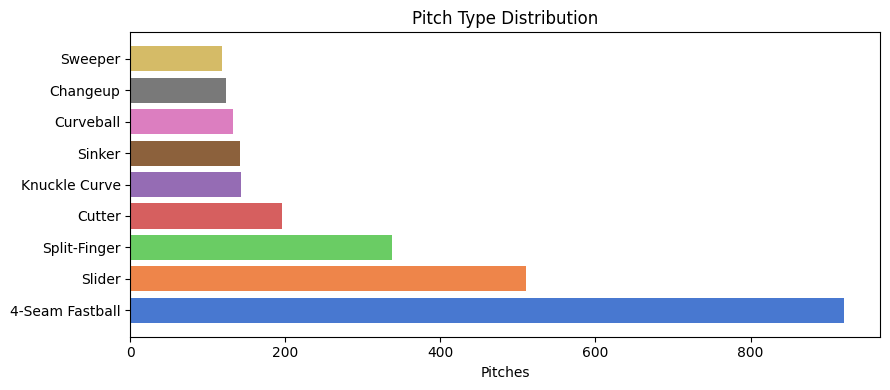

In [16]:
pitch_counts = df["pitch_name"].value_counts()
total = pitch_counts.sum()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(pitch_counts.index, pitch_counts.values, color=sns.color_palette("muted", len(pitch_counts)))

ax.set_xlabel("Pitches")
ax.set_title("Pitch Type Distribution")
plt.tight_layout()
plt.show()

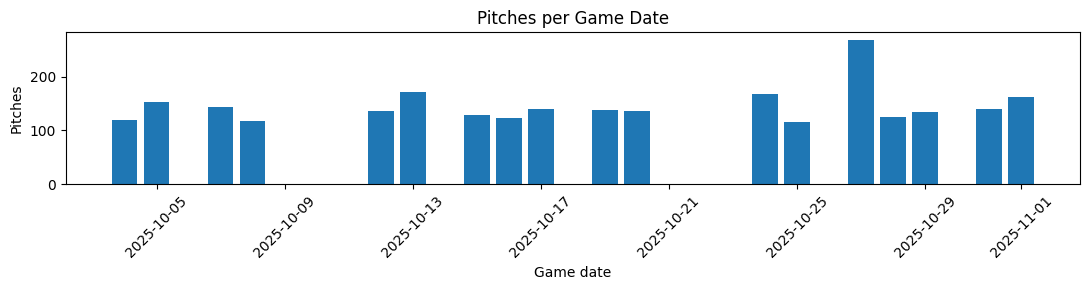

In [17]:
pitches_per_date = df.groupby("game_date").size()

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(pitches_per_date.index, pitches_per_date.values)
ax.set_xlabel("Game date")
ax.set_ylabel("Pitches")
ax.set_title("Pitches per Game Date")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

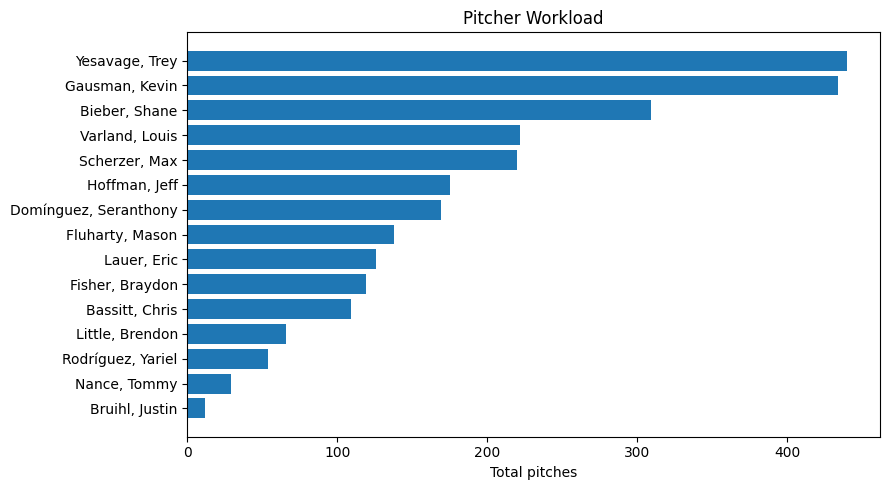

In [18]:
workload = df.groupby("player_name").size().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(workload.index, workload.values)
ax.set_xlabel("Total pitches")
ax.set_title("Pitcher Workload")
plt.tight_layout()
plt.show()

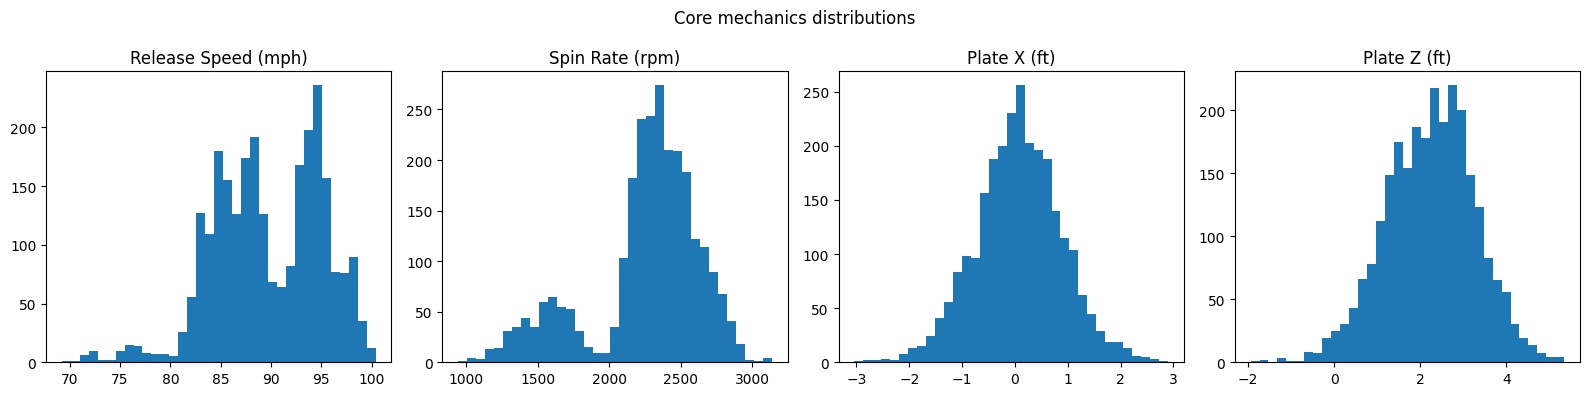

In [19]:
core_mechanics = [("release_speed", "Release Speed (mph)"), ("release_spin_rate", "Spin Rate (rpm)"), ("plate_x", "Plate X (ft)"), ("plate_z", "Plate Z (ft)")]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (col, label) in zip(axes, core_mechanics):
    ax.hist(df[col].dropna(), bins=35)
    ax.set_title(label)
plt.suptitle("Core mechanics distributions")
plt.tight_layout()
plt.show()

## Verification

In [20]:
print(f"Shape: {df.shape}")
print(f"Pitchers: {df['player_name'].nunique()} ; Games: {df['game_pk'].nunique()}")
print()
print("Core mechanic nulls:")
print(df[["release_speed", "release_spin_rate", "plate_x", "plate_z", "effective_speed"]].isnull().sum())
print()
for feat in ["cum_pitch_count", "game_phase", "score_diff"]:
    print(f"{feat}: {'ok :)' if feat in df.columns else 'no ok :('}")
print()
bad = [c for c in df.columns if "deprecated" in c or c.endswith(".1") or c.endswith(".2")]
print(f"Bad columns: {bad or 'None'}")

Shape: (2622, 88)
Pitchers: 15 ; Games: 18

Core mechanic nulls:
release_speed        0
release_spin_rate    0
plate_x              0
plate_z              0
effective_speed      0
dtype: int64

cum_pitch_count: ok :)
game_phase: ok :)
score_diff: ok :)

Bad columns: None


In [21]:
df.to_csv("dataset_cleaned.csv")